In [2]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_ta as ta
import optuna
import math


In [3]:
def load_candles(base,quote,timeframe):
    data = pd.read_json(f'/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data/binance/{base}_{quote}-{timeframe}.json')
    data.columns = ['timestamp', 'open', 'high', 'low', 'close', 'volume']
    data['timestamp'] = pd.to_datetime(data['timestamp'], unit='ms')
    data.set_index('timestamp', inplace=True)
    return data

[I 2024-08-04 01:42:26,977] A new study created in memory with name: no-name-37223868-1bf6-47c7-a793-b42f192f87ca
[I 2024-08-04 01:42:26,983] Trial 0 finished with value: 1.0186648339277098 and parameters: {'ema_fast_len': 35, 'ema_slow_len': 50, 'ema_margin_atr_len': 50, 'ema_margin_atr_mult': 0.7080122977305668}. Best is trial 0 with value: 1.0186648339277098.
[I 2024-08-04 01:42:26,988] Trial 1 finished with value: -0.09271275541368378 and parameters: {'ema_fast_len': 46, 'ema_slow_len': 91, 'ema_margin_atr_len': 44, 'ema_margin_atr_mult': 2.4001272052926064}. Best is trial 0 with value: 1.0186648339277098.
[I 2024-08-04 01:42:26,993] Trial 2 finished with value: 1.1737387419858372 and parameters: {'ema_fast_len': 18, 'ema_slow_len': 92, 'ema_margin_atr_len': 9, 'ema_margin_atr_mult': 1.840598397574809}. Best is trial 2 with value: 1.1737387419858372.
[I 2024-08-04 01:42:26,997] Trial 3 finished with value: -0.09155491496545094 and parameters: {'ema_fast_len': 38, 'ema_slow_len': 82

Best Parameters: {'ema_fast_len': 13, 'ema_slow_len': 73, 'ema_margin_atr_len': 25, 'ema_margin_atr_mult': 0.1442694935087811}


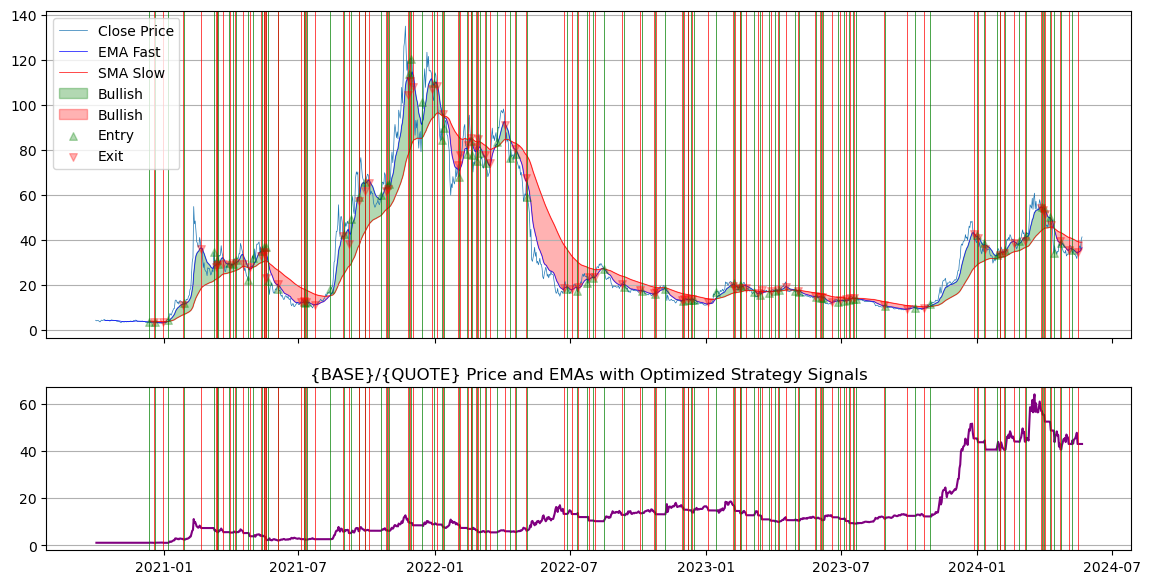

Final Cumulative Return with Optimized Parameters: 42.92
Sharpe Ratio: 2.53
Total Return: 41.92
Annualized Return: 4.84
Number of Trades: 94
Win Ratio: 0.24
Average Win: 0.0238
Average Loss: -0.0029
Best params: {'ema_fast_len': 13, 'ema_slow_len': 73, 'ema_margin_atr_len': 25, 'ema_margin_atr_mult': 0.1442694935087811}


In [49]:

# Define transaction costs and slippage
transaction_cost = 0.001  # 0.1% transaction cost per trade
slippage = 0.001  # 0.1% slippage per trade



# Define the fitness function
# def calculate_indicators(data, params):
def indicators(data, params):
    ema_fast_len, ema_slow_len, ema_margin_atr_len, ema_margin_atr_mult = params
    
    # Ensure that parameters are valid
    ema_fast_len = max(1, int(ema_fast_len))
    ema_slow_len = max(1, int(ema_slow_len))
    ema_margin_atr_len = max(1, int(ema_margin_atr_len))
    
    # Calculate indicators using pandas_ta
    data['ema_fast'] = ta.ema(data['close'], length=ema_fast_len)
    data['ema_slow'] = ta.ema(data['close'], length=ema_slow_len)
    data['atr'] = ta.atr(data['high'], data['low'], data['close'], length=ema_margin_atr_len)
    data['ema_diff'] = data['ema_fast'] - data['ema_slow']
    
    # Generate entry signals 
    data['bull'] = (data['ema_diff'] > (ema_margin_atr_mult * data['atr'])) & ((data['close'] > data['ema_fast']))
    data['bull_exit'] =  (data['close'] < data['ema_fast'])
    
    data['bear'] = ((data['ema_diff']) < (ema_margin_atr_mult * data['atr'])) & ((data['close'] < data['ema_fast']))
    data['bear_exit'] =  (data['close'] > data['ema_fast'])
    
    # Generate exit signals
    # data['exit'] = (data['close'] > data['ema_slow']) & (data['close'] < data['ema_fast'])
      
def backtest(data):

    # Initialize the 'position' column
    data['position'] = 0
    
    # # Set the 'position' column based on the signals
    data.loc[(data['bull']), 'position'] = 1        
    data.loc[(data['bull'] & data['bull_exit']), 'position'] = 0   
    # # Exit position when exit signal is True
    
    # Set the 'position' column based on the signals
    data.loc[(data['bear']), 'position'] = -1    
    data.loc[(data['bear'] & data['bear_exit']), 'position'] = 0
    # # Exit position when exit signal is True
    
    # data.loc[data['bull_exit'], 'position'] = 0    
    # data.loc[data['bear_exit'], 'position'] = 0
    
    # Forward fill the position to maintain the position until a signal changes
    # data['position'] = data['position'].replace(to_replace=0, method='ffill')
    
    # Calculate number of trades
    data['trade'] = data['position'].diff().abs()
    number_of_trades = data['trade'].sum() / 2  # Each trade consists of an entry and an exit
    
    # Calculate strategy returns
    data['strategy_returns'] = data['position'].shift(1) * data['close'].pct_change()
    
    
    # Apply transaction costs and slippage only on trades
    data['strategy_returns'] -= data['trade'] * (transaction_cost + slippage)

    data['cumulative_returns'] = (1 + data['strategy_returns']).cumprod()
    
    # Calculate performance metrics
    total_return = data['cumulative_returns'].iloc[-1] - 1
    annualized_return = data['strategy_returns'].mean() * 365 * 24 / 8  # Assuming 8-hour bars
    annualized_volatility = data['strategy_returns'].std() * np.sqrt(365 * 24 / 8)
    sharpe_ratio = annualized_return / annualized_volatility
    

    # Calculate trade returns
    data['trade_returns'] = data['strategy_returns'] * data['trade'].shift(-1)

    # Calculate winning trades and losing trades
    winning_trades = data['trade_returns'][data['trade_returns'] > 0]
    losing_trades = data['trade_returns'][data['trade_returns'] <= 0]

    # Calculate win ratio
    if number_of_trades > 0:
        win_ratio = len(winning_trades) / number_of_trades
    else:
        win_ratio = np.nan

    # Calculate average win and average loss
    average_win = winning_trades.mean() if len(winning_trades) > 0 else np.nan
    average_loss = losing_trades.mean() if len(losing_trades) > 0 else np.nan

    
    return sharpe_ratio,total_return,annualized_return,number_of_trades,win_ratio,average_win,average_loss


def optimize(data):
    # Define the objective function for Optuna
    def objective(trial):
        ema_fast_len = trial.suggest_int('ema_fast_len', 7, 50)
        ema_slow_len = trial.suggest_int('ema_slow_len', 50, 100)
        ema_margin_atr_len = trial.suggest_int('ema_margin_atr_len', 7, 50)
        ema_margin_atr_mult = trial.suggest_uniform('ema_margin_atr_mult', 0.1, 5)
        
        params = (ema_fast_len, ema_slow_len, ema_margin_atr_len, ema_margin_atr_mult)
        indicators(data,params)
        sharpe_ratio,total_return,annualized_return,number_of_trades,win_ratio,average_win,average_loss = backtest(data)
        
        return sharpe_ratio #/ math.cos(number_of_trades)

    # Run the optimization
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=100)

    # Get the best parameters
    best_params = study.best_params
    print(f"Best Parameters: {best_params}")
    return study

def print_performance(data, params, window=None):
    # Set default window to the entire DataFrame if not provided
    if window is None:
        window = data.index
    
    data = data.loc[window].copy()
    
    # ema_fast_len, ema_slow_len, ema_margin_atr_len, ema_margin_atr_mult
    indicators(data,[params['ema_fast_len'],params['ema_slow_len'],
        params['ema_margin_atr_len'],params['ema_margin_atr_mult']])
    sharpe_ratio,total_return,annualized_return,number_of_trades,win_ratio,average_win,average_loss = backtest(
        data)


    # Identify trade entries and exits
    entry_points = data.index[(data['trade'] == 1) & (data['position'] != 0)]
    exit_points = data.index[(data['trade'] == 1) & (data['position'] == 0)]

    # Ensure entry and exit points are aligned
    if len(exit_points) < len(entry_points):
        entry_points = entry_points[:-1]

    # Vectorized calculation of PnL
    entry_prices = data.loc[entry_points, 'close'].values
    exit_prices = data.loc[exit_points, 'close'].values
    trade_pnl = (exit_prices - entry_prices) / entry_prices  # Calculate percentage return
    cumulative_trade_pnl = (1 + trade_pnl).cumprod()

    # Plot the results with the best parameters
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True, height_ratios=[2,1])
    # plt.figure(figsize=(14, 3))
    ax1.plot(data.index, data['close'], label='Close Price',lw=0.5)
    ax1.plot(data.index, data['ema_fast'], label='EMA Fast', color='blue',lw=0.5)
    ax1.plot(data.index, data['ema_slow'], label='SMA Slow', color='red',lw=0.5)
    ax1.fill_between(data.index, data['ema_fast'], data['ema_slow'], where=(data['ema_diff'] > 0), color='green', alpha=0.3, label='Bullish')
    ax1.fill_between(data.index, data['ema_fast'], data['ema_slow'], where=(data['ema_diff'] < 0), color='red', alpha=0.3, label='Bullish')
    ax1.scatter(entry_points, data.loc[entry_points, 'close'], marker='^', color='g', s=30, label='Entry', zorder=5,alpha=0.3)
    ax1.scatter(exit_points, data.loc[exit_points, 'close'], marker='v', color='r', s=30, label='Exit', zorder=5,alpha=0.3)
 
    ax1.legend(loc='best')
    plt.title('{BASE}/{QUOTE} Price and EMAs with Optimized Strategy Signals')


    # ax2 = plt.twinx()
    ax2.plot(data.index, data['cumulative_returns'], label='Cumulative Returns', color='purple')
    # ax2.plot(np.append([data.index.values[0]], exit_points.values), np.append([1], cumulative_trade_pnl), label='Cumulative Returns', color='purple')
    # ax2.plot((1+data['trade_returns']).cumprod(), label='Cumulative Returns', color='purple')

    for x in entry_points: ax1.axvline(x, lw=0.5, c='green');ax2.axvline(x, lw=0.5, c='green')
    for x in exit_points: ax1.axvline(x, lw=0.5, c='red');ax2.axvline(x, lw=0.5, c='red')
    ax1.grid(axis='y')
    ax2.grid(axis='y')
    
    plt.show()

# Plot cumulative returns with the best parameters
# plt.figure(figsize=(14, 3))
# plt.plot(data.index, data['cumulative_returns'], label='Cumulative Returns', color='purple')
# plt.legend(loc='best')
# plt.title('Cumulative Returns of the Optimized Strategy')
# plt.show()

    # Print final cumulative return with the best parameters
    print(f"Final Cumulative Return with Optimized Parameters: {data['cumulative_returns'].iloc[-1]:.2f}")

    # Print performance metrics
    print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
    print(f"Total Return: {total_return:.2f}")
    print(f"Annualized Return: {annualized_return:.2f}")
    print(f"Number of Trades: {number_of_trades:.0f}")
    print(f"Win Ratio: {win_ratio:.2f}")
    print(f"Average Win: {average_win:.4f}")
    print(f"Average Loss: {average_loss:.4f}")


# Load the data

# Load the data
data = load_candles('AVAX','USDT','1d')
# data = data['2021-11-01':].copy()
study = optimize(data)
best_params = study.best_params
window = data['2020-10':'2025-01'].index
# window = None
print_performance(data,best_params,window=window)
print(f'Best params: {best_params}')

[I 2024-08-04 01:51:48,205] A new study created in memory with name: no-name-ecca3eed-1c94-4f42-a893-ec14d0c61a76
[I 2024-08-04 01:51:48,211] Trial 0 finished with value: 1.765568250631467 and parameters: {'ema_fast_len': 32, 'ema_slow_len': 73, 'ema_margin_atr_len': 47, 'ema_margin_atr_mult': 0.9564267905534848}. Best is trial 0 with value: 1.765568250631467.
[I 2024-08-04 01:51:48,216] Trial 1 finished with value: 1.5510250446189273 and parameters: {'ema_fast_len': 27, 'ema_slow_len': 85, 'ema_margin_atr_len': 41, 'ema_margin_atr_mult': 1.6200354629176303}. Best is trial 0 with value: 1.765568250631467.
[I 2024-08-04 01:51:48,220] Trial 2 finished with value: -0.4357092449387191 and parameters: {'ema_fast_len': 36, 'ema_slow_len': 65, 'ema_margin_atr_len': 8, 'ema_margin_atr_mult': 3.7284609241693847}. Best is trial 0 with value: 1.765568250631467.
[I 2024-08-04 01:51:48,225] Trial 3 finished with value: 0.8163031813312394 and parameters: {'ema_fast_len': 23, 'ema_slow_len': 97, 'ema

Best Parameters: {'ema_fast_len': 8, 'ema_slow_len': 52, 'ema_margin_atr_len': 14, 'ema_margin_atr_mult': 0.4496638296958486}


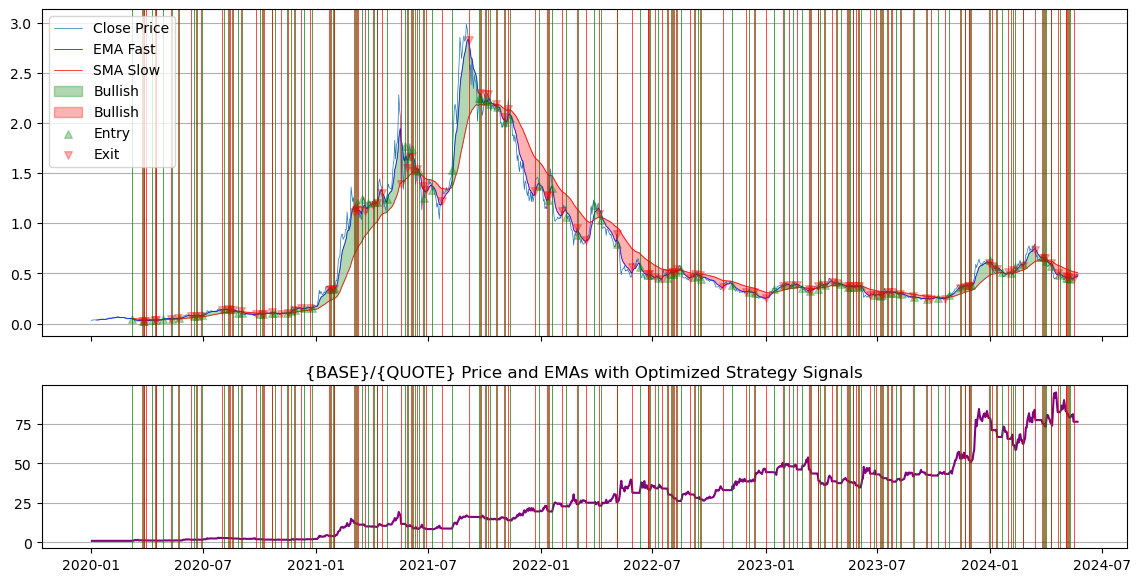

Final Cumulative Return with Optimized Parameters: 76.41
Sharpe Ratio: 3.18
Total Return: 75.41
Annualized Return: 5.08
Number of Trades: 117
Win Ratio: 0.36
Average Win: 0.0226
Average Loss: -0.0026
Best params: {'ema_fast_len': 8, 'ema_slow_len': 52, 'ema_margin_atr_len': 14, 'ema_margin_atr_mult': 0.4496638296958486}


In [73]:
# Load the data
data = load_candles('ALGO','USDT','1h')
ohlc_dict = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}

data = data.resample('31H').agg(ohlc_dict)

# data = data['2021-11-01':].copy()
study = optimize(data)
best_params = study.best_params
# window = data['2023-10':'2025-01'].index
window = None
print_performance(data,best_params,window=window)
print(f'Best params: {best_params}')

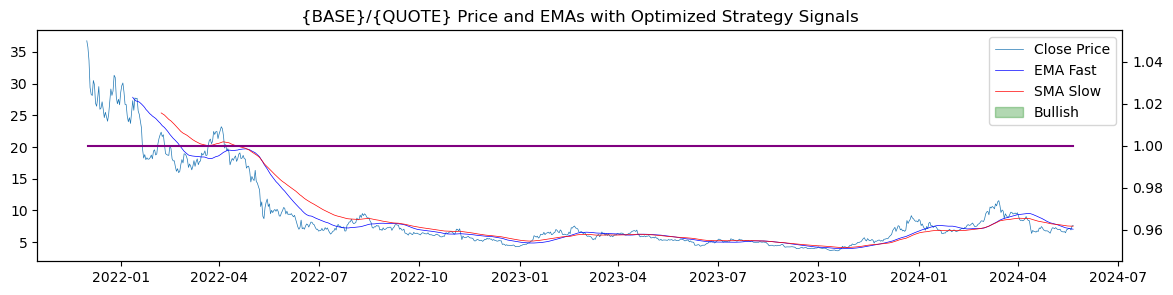

Final Cumulative Return with Optimized Parameters: 1.00
Sharpe Ratio: nan
Total Return: 0.00
Annualized Return: 0.00
Number of Trades: 0
Win Ratio: nan
Average Win: nan
Average Loss: 0.0000


In [179]:
data2 = load_candles('DOT','USDT','1d')
data2 = data2['2021-12-01':]
print_performance(data2,best_params)
